In [1]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=67fd2bdc401132fb5f2f6e3cb5cc893c20abbc7dc535d9f266acafd3b1cb3d19
  Stored in directory: /root/.cache/pip/wheels/3a/e3/70/bd8fda7b2cf8b67e234290f8a72c8124b7e8e38c87451d1bbe
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=f7bccf74a

迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_299.obj


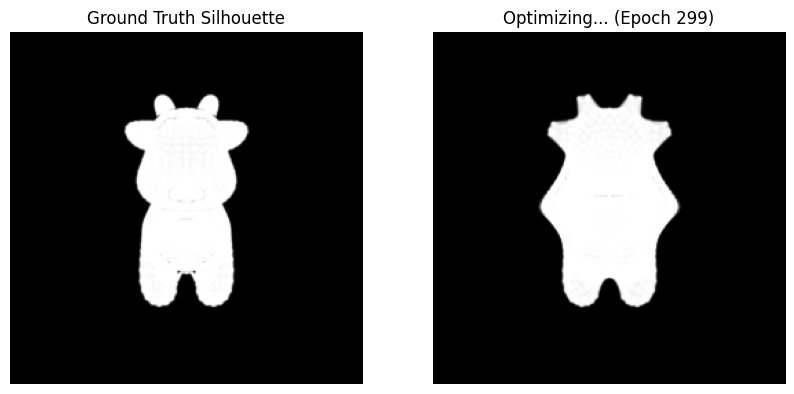

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")